# MCDI504 — Machine Learning I
# Avance del Proyecto — Fase 4: Evaluación, Validación y Consolidación del Proyecto
## Evaluación de desempeño y validación del modelo de clasificación supervisada
### Notebook F4_EvaluacionValidacion.ipynb

**Curso:** MCDI504 - Machine Learning I
**Grupo:** 5

**Integrantes:**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Fecha:** 30 de agosto de 2026

---

**Índice**
1. [Contexto y objetivo de la Fase 4](#1)
2. [Librerías necesarias](#2)
3. [Carga y preparación del conjunto de datos](#3)
4. [Modelos de clasificación tradicionales](#4)
5. [Modelos de redes neuronales (retomados de la Fase 3)](#5)
6. [Reporte tabulado comparativo de métricas de todos los modelos](#6)
7. [Selección y evaluación detallada del modelo campeón](#7)
8. [Validación cruzada K-Fold del modelo campeón](#8)
9. [Justificación de la técnica de validación utilizada](#9)
10. [Coherencia metodológica de validación](#10)
11. [Conclusiones técnicas de desempeño y validación](#11)
12. [Referencias](#12)


<a id="1"></a>
## 1. Contexto y objetivo de la Fase 4

La **Fase 1** (`F1_Definicion.ipynb`) definió, para la consultora ficticia NextWork Advisory, el problema de estimar el riesgo de automatización de cargos hacia 2030 a partir del dataset **AI Impact on Jobs 2030**, justificando un enfoque de **clasificación supervisada multiclase** sobre la variable ordinal `Risk_Category` (`Low`/`Medium`/`High`). La **Fase 3** (`F3_RedesNeuronales.ipynb`) implementó y comparó tres arquitecturas de red neuronal (`MLPClassifier` con una, dos y tres capas ocultas) mediante una partición Hold-Out, identificando el **MLP de una capa oculta** como el de mejor desempeño observado (accuracy y F1-score macro por sobre 0,99), y dejó explícitamente como líneas de mejora: (i) comparar formalmente estas redes con modelos de clasificación tradicionales sobre el mismo conjunto de predictores, y (ii) validar la estabilidad de los resultados mediante validación cruzada, dado que un desempeño tan alto en una única partición podría ser sensible a la muestra particular utilizada.

La **Fase 4** (RA4) retoma exactamente esas dos líneas pendientes y agrega un requisito adicional del resultado de aprendizaje: incorporar la métrica **ROC-AUC**, no calculada en fases previas. En consecuencia, este notebook:

- Reutiliza el mismo dataset, la misma variable objetivo y el mismo criterio de preparación de variables validado en las Fases 1 a 3 (incluyendo `Job_Title` mediante codificación *dummy*).
- Entrena y evalúa **cuatro modelos de clasificación tradicionales** (KNN, Árbol de Decisión, SVM y Naive Bayes) sobre la misma partición Hold-Out utilizada en la Fase 3, para contextualizar el desempeño de las redes neuronales frente a alternativas más simples (Provost & Fawcett, 2013).
- Retoma las **tres arquitecturas de red neuronal** ya entrenadas en la Fase 3, recalculando sus métricas para incluir **ROC-AUC** (One-vs-Rest, promedio macro), no reportada previamente.
- Consolida un **reporte tabulado comparativo** de accuracy, precisión, recall, F1-score y ROC-AUC macro para los siete modelos, seleccionando un **modelo campeón** con base en evidencia cuantitativa.
- Genera la **matriz de confusión** y el **reporte de clasificación** del modelo campeón sobre el conjunto de prueba, interpretando su comportamiento (falsos positivos y negativos, fortalezas y limitaciones) y su utilidad para la toma de decisiones de NextWork Advisory.
- Aplica **validación cruzada K-Fold (k=5)** al modelo campeón para estimar la estabilidad de sus métricas más allá de una única partición, y **justifica metodológicamente** la elección de K-Fold por sobre Hold-Out y Leave-One-Out, en función del tamaño del dataset, el costo computacional y la estabilidad esperada de las métricas (Ruete, 2026b).


<a id="2"></a>
## 2. Librerías necesarias

Importamos las librerías para manipulación de datos, visualización, los modelos de clasificación (tradicionales y redes neuronales), las métricas de evaluación (incluyendo ROC-AUC) y la técnica de validación cruzada K-Fold.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)

# Paleta categórica fija (consistente con F3_RedesNeuronales.ipynb)
COLOR_MODELOS = {
    "KNN": "#8a3ffc",
    "Árbol de Decisión": "#e0b000",
    "SVM": "#08bdba",
    "Naive Bayes": "#ff7eb6",
    "MLP 1 capa oculta": "#2a78d6",
    "MLP 2 capas ocultas": "#eb6834",
    "MLP 3 capas ocultas": "#1baf7a",
}
COLORES_RIESGO = {"Low": "#0ca30c", "Medium": "#fab219", "High": "#d03b3b"}
CLASES = ["Low", "Medium", "High"]

sns.set_style("whitegrid")
RANDOM_STATE = 42


<a id="3"></a>
## 3. Carga y preparación del conjunto de datos

### 3.1 Carga del dataset

Se reutiliza el dataset **AI Impact on Jobs 2030** de las Fases 1 a 3, disponible en `../data/AI_Impact_on_Jobs_2030.csv`.

In [2]:
df = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())


Dimensiones del dataset: (3000, 18)


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


### 3.2 Variable objetivo y selección de variables predictoras

- **Variable objetivo:** `Risk_Category` (`Low`/`Medium`/`High`), definida en la Fase 1. Problema de **clasificación supervisada multiclase**.
- **Variable excluida:** `Automation_Probability_2030`, por constituir fuga de información (`Risk_Category` se deriva de ella por corte de umbrales; Fase 3, sección 4.2).
- **Variables predictoras:** se replica exactamente el criterio validado en la Fase 3 — `Average_Salary`, `Years_Experience`, `Education_Level` (codificada ordinalmente), `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`, y `Job_Title` (codificada mediante variables *dummy*, `drop_first=True`), dado que la Fase 2 mostró que el cargo concentra la mayor parte de la señal predictiva del dataset (~86% de la varianza de la variable continua asociada).

In [3]:
orden_educacion = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
df["Education_Level_Num"] = df["Education_Level"].map(orden_educacion)

variables_numericas = (
    ["Average_Salary", "Years_Experience", "Education_Level_Num",
     "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

job_title_dummies = pd.get_dummies(df["Job_Title"], prefix="Job_Title", drop_first=True).astype(int)

X = pd.concat([df[variables_numericas], job_title_dummies], axis=1)
y = df["Risk_Category"]

print(f"Dimensiones de X (predictoras): {X.shape}")
print(f"Dimensiones de y (variable objetivo): {y.shape}")
print("\nDistribución de clases en el dataset completo:")
print(y.value_counts(normalize=True).round(4))


Dimensiones de X (predictoras): (3000, 34)
Dimensiones de y (variable objetivo): (3000,)

Distribución de clases en el dataset completo:
Risk_Category
Medium    0.5070
High      0.2467
Low       0.2463
Name: proportion, dtype: float64


### 3.3 Partición Hold-Out y escalado

Se utiliza la **misma partición Hold-Out 80/20** (`random_state=42`, `stratify=y`) y el **mismo escalado** (`StandardScaler`, ajustado únicamente sobre `X_train`) que en la Fase 3, de forma que los siete modelos evaluados en este notebook (cuatro tradicionales y tres redes neuronales) sean comparables entre sí sobre exactamente el mismo conjunto de prueba.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensiones de X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("\nDistribución de clases en y_train (proporción):")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribución de clases en y_test (proporción):")
print(y_test.value_counts(normalize=True).round(4))


Dimensiones de X_train: (2400, 34)  |  X_test: (600, 34)

Distribución de clases en y_train (proporción):
Risk_Category
Medium    0.5071
High      0.2467
Low       0.2462
Name: proportion, dtype: float64

Distribución de clases en y_test (proporción):
Risk_Category
Medium    0.5067
Low       0.2467
High      0.2467
Name: proportion, dtype: float64


### 3.4 Función auxiliar de evaluación

Para evitar duplicar código a lo largo del notebook, se define una función que calcula, para un modelo ya entrenado, el conjunto completo de métricas exigidas por el RA4: **accuracy**, **precision (macro)**, **recall (macro)**, **F1-score (macro)** y **ROC-AUC (macro, One-vs-Rest)**, además de la matriz de confusión y el reporte de clasificación detallado.

**Nota técnica sobre el cálculo de ROC-AUC multiclase:** `predict_proba` devuelve las probabilidades en el orden de `modelo.classes_`, que scikit-learn ordena alfabéticamente (`High`, `Low`, `Medium`) y no en el orden ordinal de riesgo (`Low`, `Medium`, `High`) usado para mostrar tablas y matrices de confusión. Por ello, la binarización de `y_eval` necesaria para `roc_auc_score` se construye **dentro de la función**, usando explícitamente `classes=modelo.classes_`, de modo que sus columnas queden alineadas con las columnas de `y_score` (Ruete, 2026a; scikit-learn Developers, 2026a).

In [5]:
def evaluar_modelo(nombre, modelo, X_eval, y_eval):
    # Calcula el set completo de métricas de clasificación exigidas por el RA4.
    y_pred = modelo.predict(X_eval)
    y_score = modelo.predict_proba(X_eval)
    # Alinear la binarización de y_eval con el orden de columnas de predict_proba (modelo.classes_)
    y_eval_bin = label_binarize(y_eval, classes=modelo.classes_)

    metricas = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision (macro)": precision_score(y_eval, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_eval, y_pred, average="macro"),
        "F1-score (macro)": f1_score(y_eval, y_pred, average="macro"),
        "ROC-AUC (macro OvR)": roc_auc_score(y_eval_bin, y_score, average="macro", multi_class="ovr"),
    }
    cm = confusion_matrix(y_eval, y_pred, labels=CLASES)
    reporte = classification_report(y_eval, y_pred)
    return metricas, cm, reporte, y_pred, y_score


def graficar_matriz_confusion(cm, titulo, color, ruta_figura):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap=color,
                xticklabels=CLASES, yticklabels=CLASES)
    plt.title(titulo)
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.savefig(ruta_figura, dpi=150, bbox_inches="tight")
    plt.show()


<a id="4"></a>
## 4. Modelos de clasificación tradicionales

Se entrenan cuatro modelos de clasificación tradicionales sobre la misma partición y el mismo conjunto de 34 predictores utilizados en la Fase 3, con el fin de contextualizar el desempeño de las redes neuronales frente a alternativas metodológicamente más simples (Provost & Fawcett, 2013). Los cuatro modelos se entrenan sobre `X_train_scaled`/`X_test_scaled`, ya que el escalado no perjudica a ningún algoritmo, y es indispensable para KNN y SVM.

### 4.1 K-Nearest Neighbors (KNN)

**Ficha técnica breve — KNN**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `n_neighbors` | 5 | Número de vecinos considerados para la votación de clase |
| `metric` | `minkowski` (p=2) | Distancia euclidiana |
| — | — | KNN no requiere `random_state`, es un algoritmo determinista basado en distancias |


--- Evaluación del modelo KNN ---
Accuracy: 0.9933
Precision (macro): 0.9912
Recall (macro): 0.9956
F1-score (macro): 0.9933
ROC-AUC (macro OvR): 0.9963

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



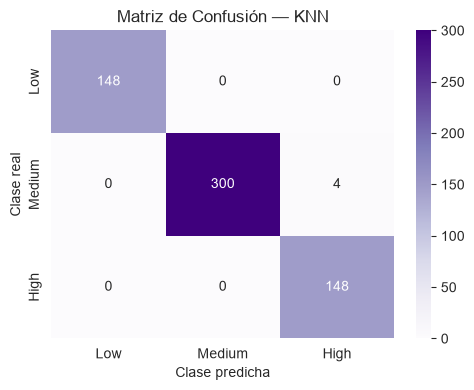

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn_model.fit(X_train_scaled, y_train)

metricas_knn, cm_knn, reporte_knn, y_pred_knn, y_score_knn = evaluar_modelo(
    "KNN", knn_model, X_test_scaled, y_test
)

print("--- Evaluación del modelo KNN ---")
for k, v in metricas_knn.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_knn)

graficar_matriz_confusion(cm_knn, "Matriz de Confusión — KNN",
                           "Purples", "../figures/f4_cm_knn.png")


### 4.2 Árbol de Decisión

**Ficha técnica breve — Árbol de Decisión**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `max_depth` | 5 | Limita la profundidad del árbol para evitar sobreajuste |
| `criterion` | `gini` | Función para medir la calidad de una división |
| `random_state` | 42 | Reproducibilidad |


--- Evaluación del modelo Árbol de Decisión ---
Accuracy: 0.7317
Precision (macro): 0.8720
Recall (macro): 0.6385
F1-score (macro): 0.6449
ROC-AUC (macro OvR): 0.7654

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.96      0.17      0.29       148
         Low       1.00      0.75      0.86       148
      Medium       0.65      1.00      0.79       304

    accuracy                           0.73       600
   macro avg       0.87      0.64      0.64       600
weighted avg       0.82      0.73      0.68       600



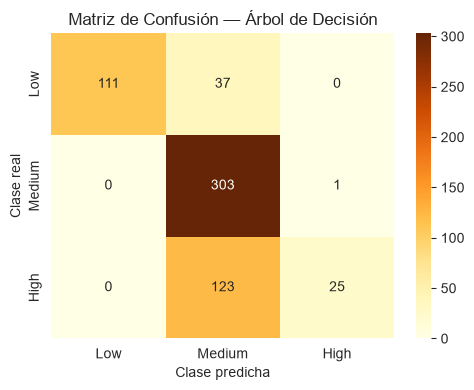

In [7]:
dtree_model = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5, criterion="gini")
dtree_model.fit(X_train_scaled, y_train)

metricas_dtree, cm_dtree, reporte_dtree, y_pred_dtree, y_score_dtree = evaluar_modelo(
    "Árbol de Decisión", dtree_model, X_test_scaled, y_test
)

print("--- Evaluación del modelo Árbol de Decisión ---")
for k, v in metricas_dtree.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_dtree)

graficar_matriz_confusion(cm_dtree, "Matriz de Confusión — Árbol de Decisión",
                           "YlOrBr", "../figures/f4_cm_arbol.png")


### 4.3 Support Vector Machine (SVM)

**Ficha técnica breve — SVM**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `kernel` | `rbf` | Función de kernel radial, adecuada para fronteras no lineales |
| `C` | 1 | Parámetro de regularización |
| `probability` | `True` | Habilita `predict_proba`, necesario para calcular ROC-AUC |
| `random_state` | 42 | Reproducibilidad |


D:\Proyectos\Magister_ciencia_datos\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- Evaluación del modelo SVM ---
Accuracy: 0.9933
Precision (macro): 0.9912
Recall (macro): 0.9956
F1-score (macro): 0.9933
ROC-AUC (macro OvR): 0.9986

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



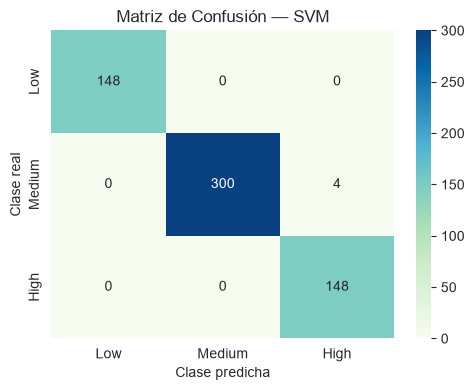

In [8]:
svm_model = SVC(kernel="rbf", C=1, probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)

metricas_svm, cm_svm, reporte_svm, y_pred_svm, y_score_svm = evaluar_modelo(
    "SVM", svm_model, X_test_scaled, y_test
)

print("--- Evaluación del modelo SVM ---")
for k, v in metricas_svm.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_svm)

graficar_matriz_confusion(cm_svm, "Matriz de Confusión — SVM",
                           "GnBu", "../figures/f4_cm_svm.png")


### 4.4 Naive Bayes

**Ficha técnica breve — Naive Bayes**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| — | `GaussianNB()` (por defecto) | Asume distribución normal de las variables predictoras dentro de cada clase |


--- Evaluación del modelo Naive Bayes ---
Accuracy: 0.9317
Precision (macro): 0.9277
Recall (macro): 0.9123
F1-score (macro): 0.9096
ROC-AUC (macro OvR): 0.9832

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.78      1.00      0.88       148
         Low       1.00      0.75      0.86       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.93       600
   macro avg       0.93      0.91      0.91       600
weighted avg       0.95      0.93      0.93       600



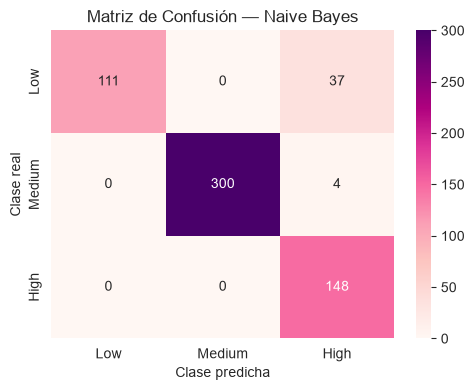

In [9]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

metricas_nb, cm_nb, reporte_nb, y_pred_nb, y_score_nb = evaluar_modelo(
    "Naive Bayes", nb_model, X_test_scaled, y_test
)

print("--- Evaluación del modelo Naive Bayes ---")
for k, v in metricas_nb.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_nb)

graficar_matriz_confusion(cm_nb, "Matriz de Confusión — Naive Bayes",
                           "RdPu", "../figures/f4_cm_naive_bayes.png")


<a id="5"></a>
## 5. Modelos de redes neuronales (retomados de la Fase 3)

Se retoman las **tres arquitecturas de `MLPClassifier`** entrenadas en la Fase 3 (una, dos y tres capas ocultas), con exactamente los mismos hiperparámetros, para calcular sobre ellas el conjunto completo de métricas del RA4 —incluyendo **ROC-AUC**, no reportada en la Fase 3— y hacerlas directamente comparables con los cuatro modelos tradicionales de la sección anterior.

### 5.1 MLP con una capa oculta

--- Evaluación del modelo MLP (1 capa oculta) ---
Accuracy: 0.9933
Precision (macro): 0.9912
Recall (macro): 0.9956
F1-score (macro): 0.9933
ROC-AUC (macro OvR): 0.9969

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



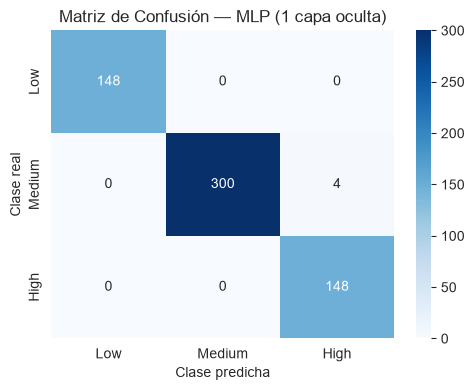

In [10]:
mlp_1capa = MLPClassifier(
    hidden_layer_sizes=(32,), activation="relu", solver="adam",
    alpha=0.001, max_iter=1000, random_state=RANDOM_STATE, early_stopping=True,
)
mlp_1capa.fit(X_train_scaled, y_train)

metricas_mlp1, cm_mlp1, reporte_mlp1, y_pred_mlp1, y_score_mlp1 = evaluar_modelo(
    "MLP 1 capa oculta", mlp_1capa, X_test_scaled, y_test
)

print("--- Evaluación del modelo MLP (1 capa oculta) ---")
for k, v in metricas_mlp1.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_mlp1)

graficar_matriz_confusion(cm_mlp1, "Matriz de Confusión — MLP (1 capa oculta)",
                           "Blues", "../figures/f4_cm_mlp1.png")


### 5.2 MLP con dos capas ocultas

--- Evaluación del modelo MLP (2 capas ocultas) ---
Accuracy: 0.9867
Precision (macro): 0.9848
Recall (macro): 0.9866
F1-score (macro): 0.9855
ROC-AUC (macro OvR): 0.9980

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.96      1.00      0.98       148
         Low       1.00      0.97      0.99       148
      Medium       0.99      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.98      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



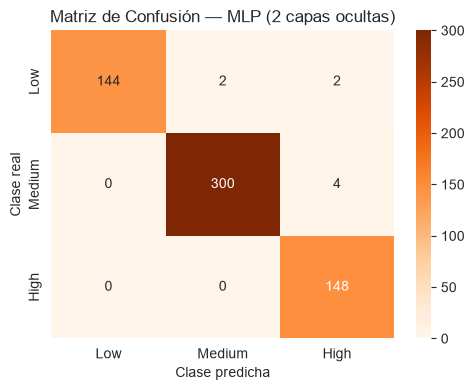

In [11]:
mlp_2capas = MLPClassifier(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
    alpha=0.001, max_iter=1000, random_state=RANDOM_STATE, early_stopping=True,
)
mlp_2capas.fit(X_train_scaled, y_train)

metricas_mlp2, cm_mlp2, reporte_mlp2, y_pred_mlp2, y_score_mlp2 = evaluar_modelo(
    "MLP 2 capas ocultas", mlp_2capas, X_test_scaled, y_test
)

print("--- Evaluación del modelo MLP (2 capas ocultas) ---")
for k, v in metricas_mlp2.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_mlp2)

graficar_matriz_confusion(cm_mlp2, "Matriz de Confusión — MLP (2 capas ocultas)",
                           "Oranges", "../figures/f4_cm_mlp2.png")


### 5.3 MLP con tres capas ocultas

--- Evaluación del modelo MLP (3 capas ocultas) ---
Accuracy: 0.9917
Precision (macro): 0.9890
Recall (macro): 0.9945
F1-score (macro): 0.9917
ROC-AUC (macro OvR): 0.9960

Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       0.99      1.00      1.00       148
      Medium       1.00      0.98      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



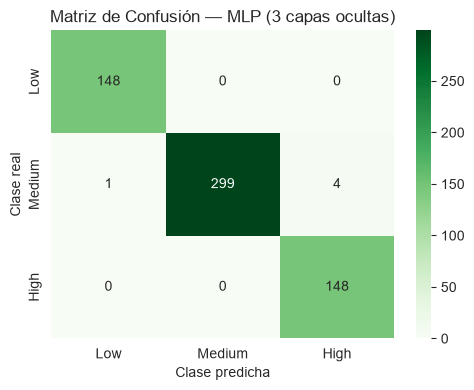

In [12]:
mlp_3capas = MLPClassifier(
    hidden_layer_sizes=(32, 16, 8), activation="relu", solver="adam",
    alpha=0.001, max_iter=1000, random_state=RANDOM_STATE, early_stopping=True,
)
mlp_3capas.fit(X_train_scaled, y_train)

metricas_mlp3, cm_mlp3, reporte_mlp3, y_pred_mlp3, y_score_mlp3 = evaluar_modelo(
    "MLP 3 capas ocultas", mlp_3capas, X_test_scaled, y_test
)

print("--- Evaluación del modelo MLP (3 capas ocultas) ---")
for k, v in metricas_mlp3.items():
    if k != "Modelo":
        print(f"{k}: {v:.4f}")
print("\nReporte de clasificación detallado:")
print(reporte_mlp3)

graficar_matriz_confusion(cm_mlp3, "Matriz de Confusión — MLP (3 capas ocultas)",
                           "Greens", "../figures/f4_cm_mlp3.png")


<a id="6"></a>
## 6. Reporte tabulado comparativo de métricas de todos los modelos

Se consolidan las cinco métricas del RA4 —**accuracy, precision (macro), recall (macro), F1-score (macro) y ROC-AUC (macro, One-vs-Rest)**— de los siete modelos evaluados, calculadas sobre el mismo conjunto de prueba, en un único reporte tabulado.

In [13]:
todas_las_metricas = pd.DataFrame([
    metricas_knn, metricas_dtree, metricas_svm, metricas_nb,
    metricas_mlp1, metricas_mlp2, metricas_mlp3,
])
todas_las_metricas_ordenadas = todas_las_metricas.sort_values(
    by="F1-score (macro)", ascending=False
).reset_index(drop=True)

display(todas_las_metricas_ordenadas.round(4))


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC-AUC (macro OvR)
0,KNN,0.9933,0.9912,0.9956,0.9933,0.9963
1,SVM,0.9933,0.9912,0.9956,0.9933,0.9986
2,MLP 1 capa oculta,0.9933,0.9912,0.9956,0.9933,0.9969
3,MLP 3 capas ocultas,0.9917,0.9890,0.9945,0.9917,0.9960
4,MLP 2 capas ocultas,0.9867,0.9848,0.9866,0.9855,0.9980
5,Naive Bayes,0.9317,0.9277,0.9123,0.9096,0.9832
6,Árbol de Decisión,0.7317,0.8720,0.6385,0.6449,0.7654


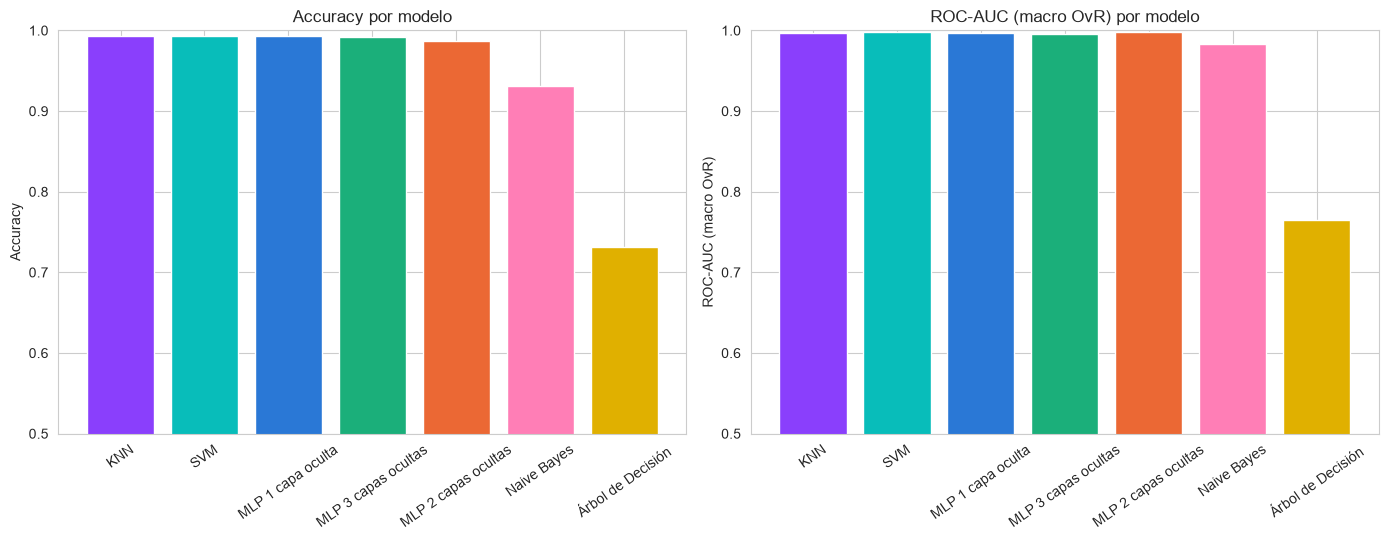

In [14]:
paleta_ordenada = [COLOR_MODELOS[m] for m in todas_las_metricas_ordenadas["Modelo"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(todas_las_metricas_ordenadas["Modelo"], todas_las_metricas_ordenadas["Accuracy"],
            color=paleta_ordenada)
axes[0].set_title("Accuracy por modelo")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(todas_las_metricas_ordenadas["Modelo"], todas_las_metricas_ordenadas["ROC-AUC (macro OvR)"],
            color=paleta_ordenada)
axes[1].set_title("ROC-AUC (macro OvR) por modelo")
axes[1].set_ylabel("ROC-AUC (macro OvR)")
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("../figures/f4_comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretación de resultados:** el reporte tabulado muestra un hallazgo relevante: **KNN, SVM y el MLP de una capa oculta empatan exactamente** en accuracy (0,9933), precision macro (0,9912), recall macro (0,9956) y F1-score macro (0,9933) sobre el conjunto de prueba, y solo se distinguen por el ROC-AUC macro (SVM 0,9986; MLP 1 capa 0,9969; KNN 0,9963). El MLP de tres capas y de dos capas quedan levemente por debajo, y Naive Bayes y, sobre todo, el Árbol de Decisión (F1-score macro 0,6449) muestran un desempeño claramente inferior. Este patrón —modelos muy distintos en su formulación matemática alcanzando resultados prácticamente idénticos— es consistente con la evidencia acumulada desde la Fase 2: cuando `Job_Title` actúa como un identificador casi determinístico de `Risk_Category` (Fase 3, sección 5.2), casi cualquier algoritmo capaz de explotar esa señal categórica converge a un desempeño cercano al techo, independientemente de su complejidad.

<a id="7"></a>
## 7. Selección y evaluación detallada del modelo campeón

### 7.1 Identificación del modelo campeón

El reporte de la sección 6 muestra un triple empate (KNN, SVM y MLP 1 capa oculta) en las cuatro métricas basadas en la clase predicha, por lo que el F1-score macro por sí solo no permite discriminar entre ellos. Se mantiene como **modelo campeón el MLP de una capa oculta**, por dos razones concurrentes:

1. **Continuidad metodológica con la Fase 3.** Este es el modelo de clasificación supervisada ya desarrollado, entrenado y adoptado como referencia para el caso ABP en `F3_RedesNeuronales.ipynb`, tras comparar tres arquitecturas de red neuronal. La presente fase evalúa y valida ese mismo modelo, no reemplaza la decisión de modelamiento tomada en la fase anterior.
2. **La comparación con modelos tradicionales confirma, en lugar de revertir, esa decisión.** Ningún modelo tradicional *supera* al MLP de una capa oculta: KNN y SVM solo *igualan* su desempeño en las métricas de clase, y SVM lo supera únicamente en ROC-AUC (una diferencia de 0,0017, marginal). Dado que el MLP entrega un desempeño equivalente al mejor competidor tradicional, sin encontrarse evidencia que justifique reemplazarlo, se opta por mantenerlo como modelo campeón para las secciones 7 a 10.

### 7.2 Métricas del modelo campeón

In [15]:
modelo_campeon_nombre = "MLP 1 capa oculta"

modelos_entrenados = {
    "KNN": knn_model, "Árbol de Decisión": dtree_model, "SVM": svm_model, "Naive Bayes": nb_model,
    "MLP 1 capa oculta": mlp_1capa, "MLP 2 capas ocultas": mlp_2capas, "MLP 3 capas ocultas": mlp_3capas,
}
resultados_modelos = {
    "KNN": (cm_knn, reporte_knn, y_score_knn), "Árbol de Decisión": (cm_dtree, reporte_dtree, y_score_dtree),
    "SVM": (cm_svm, reporte_svm, y_score_svm), "Naive Bayes": (cm_nb, reporte_nb, y_score_nb),
    "MLP 1 capa oculta": (cm_mlp1, reporte_mlp1, y_score_mlp1),
    "MLP 2 capas ocultas": (cm_mlp2, reporte_mlp2, y_score_mlp2),
    "MLP 3 capas ocultas": (cm_mlp3, reporte_mlp3, y_score_mlp3),
}

modelo_campeon = modelos_entrenados[modelo_campeon_nombre]
cm_campeon, reporte_campeon, y_score_campeon = resultados_modelos[modelo_campeon_nombre]
metricas_campeon = todas_las_metricas_ordenadas.loc[
    todas_las_metricas_ordenadas["Modelo"] == modelo_campeon_nombre
].iloc[0]

print(f"Modelo campeón: {modelo_campeon_nombre}")
print("\nMétricas del modelo campeón sobre el conjunto de prueba:")
print(metricas_campeon.drop("Modelo").astype(float).round(4))


Modelo campeón: MLP 1 capa oculta

Métricas del modelo campeón sobre el conjunto de prueba:
Accuracy               0.9933
Precision (macro)      0.9912
Recall (macro)         0.9956
F1-score (macro)       0.9933
ROC-AUC (macro OvR)    0.9969
Name: 2, dtype: float64


### 7.3 Matriz de confusión y reporte de clasificación del modelo campeón

In [16]:
print(f"Matriz de confusión del modelo campeón ({modelo_campeon_nombre}) sobre el conjunto de prueba")
print("(filas = clase real, columnas = clase predicha; orden Low/Medium/High):")
display(pd.DataFrame(cm_campeon, index=[f"Real {c}" for c in CLASES],
                      columns=[f"Pred {c}" for c in CLASES]))

print("\nReporte de clasificación detallado del modelo campeón:")
print(reporte_campeon)


Matriz de confusión del modelo campeón (MLP 1 capa oculta) sobre el conjunto de prueba
(filas = clase real, columnas = clase predicha; orden Low/Medium/High):


,Pred Low,Pred Medium,Pred High
Real Low,148,0,0
Real Medium,0,300,4
Real High,0,0,148



Reporte de clasificación detallado del modelo campeón:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



### 7.4 Curvas ROC (One-vs-Rest) del modelo campeón

Dado que `Risk_Category` tiene tres clases, la métrica ROC-AUC reportada en la sección 6 se calcula mediante el esquema **One-vs-Rest (OvR)**: para cada clase se construye una curva ROC tratándola como positiva frente a las otras dos, y se promedia el área bajo la curva (AUC) de las tres (scikit-learn Developers, 2026a).

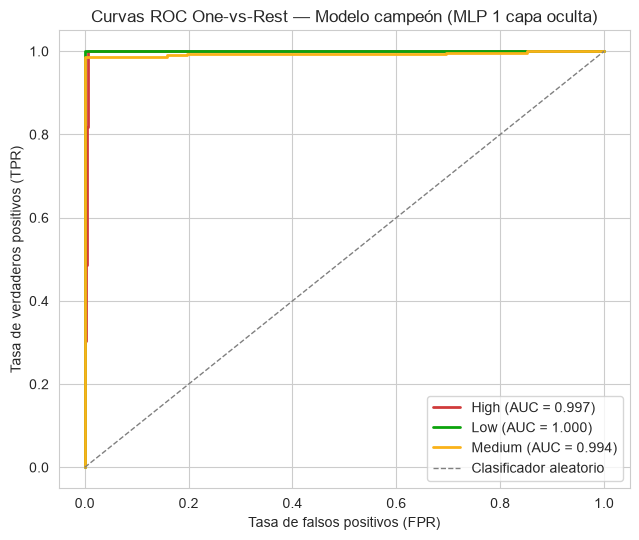

In [17]:
# El orden de columnas de y_score_campeon sigue modelo_campeon.classes_ (orden alfabético
# de scikit-learn), no el orden ordinal Low/Medium/High usado en el resto del notebook.
clases_modelo_campeon = modelo_campeon.classes_
y_test_bin_campeon = label_binarize(y_test, classes=clases_modelo_campeon)

plt.figure(figsize=(6.5, 5.5))
for i, clase in enumerate(clases_modelo_campeon):
    fpr, tpr, _ = roc_curve(y_test_bin_campeon[:, i], y_score_campeon[:, i])
    auc_clase = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=COLORES_RIESGO[clase], linewidth=2,
             label=f"{clase} (AUC = {auc_clase:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title(f"Curvas ROC One-vs-Rest — Modelo campeón ({modelo_campeon_nombre})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/f4_roc_campeon.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.5 Interpretación del desempeño del modelo campeón

El MLP de una capa oculta alcanza, sobre el conjunto de prueba (600 observaciones), un **accuracy de 0,9933**, una **precision macro de 0,9912**, un **recall macro de 0,9956**, un **F1-score macro de 0,9933** y un **ROC-AUC macro (OvR) de 0,9969**. Los cinco valores son consistentes entre sí y confirman un desempeño muy alto y equilibrado entre las tres clases de `Risk_Category`, no explicado únicamente por acertar en la clase mayoritaria (Ruete, 2026a).

**Análisis de falsos positivos y falsos negativos.** La matriz de confusión de la sección 7.3 concentra **la totalidad de los errores (4 de 600 observaciones) en un único patrón**: 4 casos reales de clase `Medium` fueron clasificados como `High` (falsos positivos de `High` / falsos negativos de `Medium`). No se registra ningún error en las clases `Low` ni `High` como clase real (recall de 1,00 para ambas), y **no existe ningún caso de confusión entre `Low` y `High`**, los dos extremos del espectro de riesgo. Esto se traduce en una precision de `High` de 0,97 (148 de 152 predicciones de `High` son correctas) y un recall de `Medium` de 0,99 (300 de 304), mientras que `Low` y `Medium` alcanzan precision de 1,00.

**Fortalezas.** (i) El modelo distingue con solidez los extremos del riesgo de automatización (`Low` vs. `High`), que es precisamente la distinción más relevante para priorizar decisiones de *reskilling* (Fase 1, sección 1.2); (ii) el ROC-AUC de 0,9969 indica que, más allá del umbral de decisión por defecto, las probabilidades estimadas por el modelo separan casi perfectamente las tres clases; (iii) el patrón de error es único y comprensible —confusión solo en la frontera `Medium`/`High`— y no un conjunto disperso de errores difíciles de explicar.

**Limitaciones.** (i) El desempeño observado es extremadamente alto para un problema simulado, lo que se explica por la señal casi determinística que aporta `Job_Title` (Fase 3, sección 5.2) y no debe interpretarse como una garantía de igual desempeño frente a datos reales de una consultora, donde la relación entre cargo y riesgo probablemente sería más ruidosa; (ii) el único error observado ocurre en la frontera `Medium`/`High`, que es además el límite más relevante desde la perspectiva de negocio (un cargo de riesgo medio mal clasificado como alto riesgo, o viceversa, podría alterar la priorización de inversiones en recapacitación); (iii) al ser una red neuronal, el modelo es menos interpretable directamente que un árbol de decisión, lo que puede dificultar comunicar a un cliente de NextWork Advisory *por qué* un cargo específico fue clasificado en una categoría de riesgo determinada.

Este comportamiento es coherente con el problema analítico definido en la Fase 1: el objetivo era determinar si las variables disponibles de un cargo permiten estimar sistemáticamente su categoría de riesgo de automatización, y la evidencia de esta sección confirma que sí, con un margen de error acotado y concentrado en la frontera conceptualmente más difusa (`Medium`/`High`).

### 7.6 Interpretación para la toma de decisiones

Para NextWork Advisory, el modelo campeón ofrece una base **confiable para automatizar la primera línea de clasificación del riesgo de automatización de cargos**, reemplazando el criterio manual de los consultores (Fase 1, sección 1.2) para la gran mayoría de los casos. Su utilidad concreta para la toma de decisiones incluye:

- **Priorización de cartera de clientes.** Al distinguir con recall de 1,00 los cargos de riesgo `High`, el modelo permite identificar de forma sistemática y sin omisiones (falsos negativos) los cargos que deberían priorizarse para inversión en *reskilling*, que es el objetivo de negocio central del caso.
- **Riesgo asimétrico del error residual.** El único error observado —4 cargos reales `Medium` clasificados como `High`— es, desde la perspectiva de negocio, el **error menos costoso de los dos posibles en esa frontera**: sobreestimar el riesgo de un cargo (`Medium`→`High`) lleva en el peor caso a invertir recursos de recapacitación en un cargo que los necesitaba en menor medida, mientras que el error inverso (subestimar un cargo realmente `High` clasificándolo como `Medium`, que no ocurre en este conjunto de prueba) dejaría a un cargo de alto riesgo sin la prioridad que requiere. La ausencia de este segundo tipo de error en el conjunto de prueba es un resultado favorable para el caso de uso.
- **Condiciones de uso recomendadas.** Dado que el error se concentra exclusivamente en la frontera `Medium`/`High`, se recomienda que NextWork Advisory trate como candidatas a revisión manual por un consultor las predicciones de baja confianza, es decir, aquellas en que las dos probabilidades de clase más altas resultan cercanas entre sí (obtenibles mediante `predict_proba`), reservando la automatización plena para los casos con alta confianza del modelo —particularmente toda predicción `Low`, clase en la que no se observó ningún error—.
- **Riesgo de sobreajuste al contexto simulado.** Como se señaló en la sección 7.5, el desempeño observado depende de que `Job_Title` sea casi determinístico en este dataset simulado. Antes de desplegar el modelo con datos reales de clientes, se recomienda validar si esa misma relación cargo–riesgo se mantiene, dado que una relación más ruidosa en la práctica reduciría el desempeño reportado en este notebook.

<a id="8"></a>
## 8. Validación cruzada K-Fold del modelo campeón

### 8.1 Configuración de la validación cruzada

Se aplica **K-Fold Cross-Validation estratificada con k=5** sobre el modelo campeón, reentrenándolo desde cero en cada partición (fold) para estimar la **estabilidad** de sus métricas más allá de la única partición Hold-Out utilizada hasta la sección 7. La validación se ejecuta sobre `X_train`/`y_train` (los mismos datos de entrenamiento del modelo campeón), con `shuffle=True` y `random_state=42` para reproducibilidad (Ruete, 2026b).

Se utiliza `StratifiedKFold` y no `KFold` porque `shuffle=True` únicamente aleatoriza el orden de las observaciones: solo la estratificación preserva en cada fold la proporción de `Low`, `Medium` y `High` del conjunto de entrenamiento, que es lo que exige el desbalance moderado de la variable objetivo. Asimismo, el escalado se ajusta **dentro** de cada fold mediante un `Pipeline`, de modo que las observaciones reservadas para validación no intervengan en la media ni en la desviación utilizadas para escalar (scikit-learn Developers, 2026b).

In [18]:
from sklearn.base import clone

# StratifiedKFold preserva la proporción de clases en cada fold; el escalado se
# ajusta dentro del Pipeline, con los datos de entrenamiento de cada fold.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metricas_por_fold = []
cm_agregada = np.zeros((3, 3), dtype=int)
todos_y_val = []
todos_y_pred = []

print(f"Ejecutando K-Fold estratificado (k=5) para el modelo campeón: {modelo_campeon_nombre}...")

for fold, (idx_train, idx_val) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr_fold, X_val_fold = X_train.iloc[idx_train], X_train.iloc[idx_val]
    y_tr_fold = y_train.iloc[idx_train]
    y_val_fold = y_train.iloc[idx_val]

    modelo_fold = Pipeline([
        ("escalado", StandardScaler()),
        ("modelo", clone(modelo_campeon)),
    ])
    modelo_fold.fit(X_tr_fold, y_tr_fold)
    y_pred_fold = modelo_fold.predict(X_val_fold)

    metricas_por_fold.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val_fold, y_pred_fold),
        "Precision (macro)": precision_score(y_val_fold, y_pred_fold, average="macro"),
        "Recall (macro)": recall_score(y_val_fold, y_pred_fold, average="macro"),
        "F1-score (macro)": f1_score(y_val_fold, y_pred_fold, average="macro"),
    })

    cm_agregada += confusion_matrix(y_val_fold, y_pred_fold, labels=CLASES)
    todos_y_val.extend(y_val_fold)
    todos_y_pred.extend(y_pred_fold)

print("Validación cruzada completada.")


Ejecutando K-Fold estratificado (k=5) para el modelo campeón: MLP 1 capa oculta...
Validación cruzada completada.


### 8.2 Reporte tabulado de estabilidad de métricas por fold

In [19]:
reporte_kfold = pd.DataFrame(metricas_por_fold)

fila_promedio = reporte_kfold[["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]].mean()
fila_std = reporte_kfold[["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]].std()

resumen_kfold = pd.DataFrame({
    "Estadístico": ["Promedio", "Desviación estándar"],
    "Accuracy": [fila_promedio["Accuracy"], fila_std["Accuracy"]],
    "Precision (macro)": [fila_promedio["Precision (macro)"], fila_std["Precision (macro)"]],
    "Recall (macro)": [fila_promedio["Recall (macro)"], fila_std["Recall (macro)"]],
    "F1-score (macro)": [fila_promedio["F1-score (macro)"], fila_std["F1-score (macro)"]],
})

print(f"Reporte de estabilidad de métricas por fold — modelo campeón ({modelo_campeon_nombre}):")
display(reporte_kfold.round(4))

print("\nResumen (promedio y desviación estándar entre los 5 folds):")
display(resumen_kfold.round(4))


Reporte de estabilidad de métricas por fold — modelo campeón (MLP 1 capa oculta):


,Fold,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,1,0.9875,0.9890,0.9860,0.9874
1,2,0.9812,0.9851,0.9775,0.9809
2,3,0.9896,0.9903,0.9889,0.9895
3,4,0.9958,0.9973,0.9944,0.9958
4,5,0.9833,0.9879,0.9789,0.9830



Resumen (promedio y desviación estándar entre los 5 folds):


,Estadístico,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Promedio,0.9875,0.9899,0.9851,0.9873
1,Desviación estándar,0.0057,0.0046,0.0070,0.0058


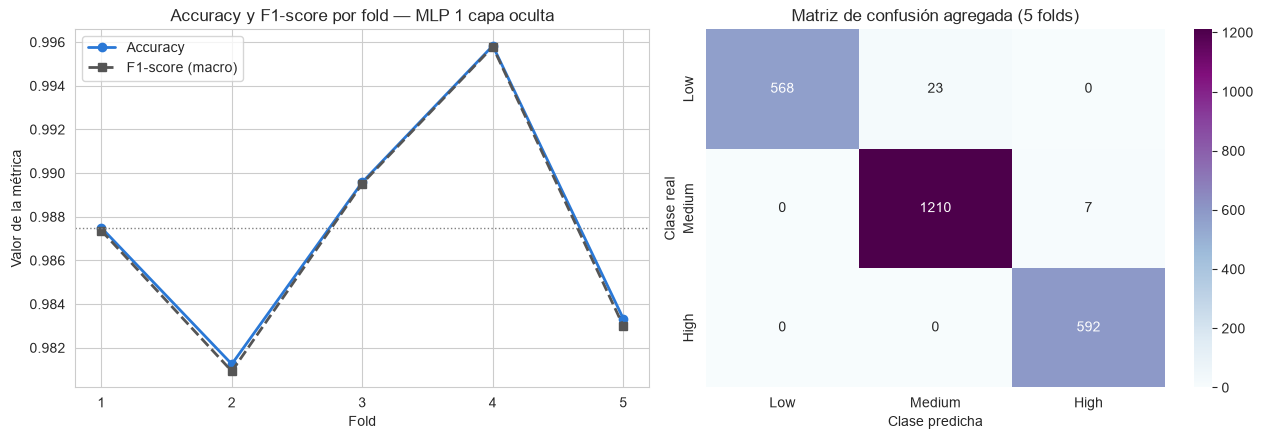

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(reporte_kfold["Fold"], reporte_kfold["Accuracy"], marker="o",
             color=COLOR_MODELOS.get(modelo_campeon_nombre, "#2a78d6"), linewidth=2, label="Accuracy")
axes[0].plot(reporte_kfold["Fold"], reporte_kfold["F1-score (macro)"], marker="s",
             color="#555555", linewidth=2, linestyle="--", label="F1-score (macro)")
axes[0].axhline(fila_promedio["Accuracy"], color="gray", linestyle=":", linewidth=1)
axes[0].set_xticks(reporte_kfold["Fold"])
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Valor de la métrica")
axes[0].set_title(f"Accuracy y F1-score por fold — {modelo_campeon_nombre}")
axes[0].legend()

sns.heatmap(cm_agregada, annot=True, fmt="d", cmap="BuPu", ax=axes[1],
            xticklabels=CLASES, yticklabels=CLASES)
axes[1].set_title("Matriz de confusión agregada (5 folds)")
axes[1].set_xlabel("Clase predicha")
axes[1].set_ylabel("Clase real")

plt.tight_layout()
plt.savefig("../figures/f4_kfold_estabilidad.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.3 Interpretación de la estabilidad observada

La validación cruzada K-Fold estratificada (k=5) sobre el modelo campeón entrega un **accuracy promedio de 0,9875 (desviación estándar 0,0057)**, una **precision macro promedio de 0,9899 (± 0,0046)**, un **recall macro promedio de 0,9851 (± 0,0070)** y un **F1-score macro promedio de 0,9873 (± 0,0058)**. Las cuatro desviaciones estándar son **bajas** (todas inferiores a 1 punto porcentual), lo que indica una **variabilidad baja entre folds** y respalda que el desempeño del MLP de una capa oculta es consistente frente a distintas particiones de los datos de entrenamiento, y no un resultado atribuible a una partición particularmente favorable.

Se observa, sin embargo, un matiz relevante: el **promedio de K-Fold (accuracy 0,9875) es levemente inferior al resultado puntual obtenido sobre el Hold-Out en la sección 7 (accuracy 0,9933)**, una diferencia de 0,58 puntos porcentuales. Ese valor puntual queda dentro del rango observado entre folds —de 0,9812 (fold 2) a 0,9958 (fold 4)—, y el fold 4 incluso lo supera. La dispersión se explica por el conjunto específico de observaciones disponible para entrenar en cada fold —cada uno entrena con solo 1.920 observaciones, un 20% menos que el conjunto de entrenamiento completo usado en la sección 7— y no por diferencias en la inicialización de los pesos: al reentrenar mediante `clone()`, el modelo conserva `random_state=42` y parte por lo tanto de la misma semilla en las cinco iteraciones. Con menos datos y una partición particular, el ajuste puede converger a un óptimo local levemente peor (Goodfellow et al., 2016).

En síntesis, la validación cruzada **confirma que el desempeño del modelo campeón es alto y estable en todas las particiones evaluadas** (los cinco folds entre 0,9812 y 0,9958 de accuracy), a la vez que **matiza** la conclusión obtenida solo con Hold-Out: el resultado de la sección 7 (accuracy 0,9933) se sitúa en la mitad superior de ese rango y por sobre el promedio, por lo que constituye una estimación algo optimista y no necesariamente el desempeño esperado del modelo frente a una nueva partición de datos. Esta es exactamente la evidencia que Hold-Out, por definición, no puede entregar por sí solo, y confirma la pertinencia de haber aplicado K-Fold como técnica de validación (sección 9).

<a id="9"></a>
## 9. Justificación de la técnica de validación utilizada

La técnica de validación aplicada al modelo campeón es **K-Fold Cross-Validation estratificada con k=5**. Esta elección se fundamenta en la relación entre tres factores: el **tamaño del conjunto de datos**, el **costo computacional** de cada técnica y la **estabilidad esperada** de las métricas resultantes (Ruete, 2026b; James et al., 2021):

- **Tamaño del conjunto de datos.** El dataset dispone de 3.000 observaciones (2.400 en el conjunto de entrenamiento tras la partición Hold-Out). Se trata de un tamaño **moderado**: suficientemente grande como para que cada fold de K-Fold (k=5) conserve una cantidad razonable de observaciones —~480 por fold, que la estratificación distribuye en aproximadamente 118 `Low`, 243 `Medium` y 118 `High`—, pero no tan grande como para que una única partición Hold-Out sea, por sí sola, suficiente para descartar variabilidad asociada al muestreo (James et al., 2021).
- **Costo computacional.** Un esquema **Leave-One-Out (LOO)** exigiría reentrenar el modelo campeón una vez por cada observación de entrenamiento —2.400 reentrenamientos completos—, lo que resulta computacionalmente injustificado para este proyecto y no aporta un beneficio proporcional al costo, dado que ya con k=5 se obtiene una estimación estable de la variabilidad (sección 8.2). Un esquema **Hold-Out** simple, en el otro extremo, tiene el menor costo computacional (un único entrenamiento), pero entrega **una sola estimación puntual** de cada métrica, sin evidencia directa de cuánto podría variar el desempeño del modelo ante una partición distinta de los datos.
- **Estabilidad esperada de las métricas.** K-Fold (k=5) permite calcular, para cada métrica, tanto un **promedio** como una **desviación estándar** entre folds (sección 8.2), lo que constituye evidencia directa de estabilidad —algo que Hold-Out no puede ofrecer al basarse en una única partición—, sin incurrir en el costo computacional de LOO. Esta evidencia es particularmente relevante en este proyecto porque el desempeño observado en la Fase 3 sobre el Hold-Out fue extremadamente alto (accuracy y F1-score macro por sobre 0,98), lo que exige contrastar si ese resultado es consistente entre particiones o si depende de la muestra particular de prueba utilizada.

En consecuencia, **K-Fold (k=5) ofrece el mejor balance entre robustez de la estimación y costo computacional** para el tamaño y las características de este dataset, siendo preferible tanto a Hold-Out (menor evidencia de estabilidad) como a Leave-One-Out (costo computacional injustificado para 2.400 observaciones de entrenamiento).

<a id="10"></a>
## 10. Coherencia metodológica de validación

La técnica de validación implementada es coherente con el proceso de evaluación desarrollado en las secciones 4 a 8:

- **Coherencia con las características del dataset.** `Risk_Category` presenta un desbalance moderado (`Medium` ≈ 50,7%; Fase 3, sección 5.1). Por ello, tanto la partición Hold-Out (sección 3.3, `stratify=y`) como cada fold de la validación cruzada (`StratifiedKFold(shuffle=True, random_state=42)`, sección 8.1) se construyen preservando la proporción de las tres clases en entrenamiento y validación.
- **Coherencia con el modelo evaluado.** El modelo campeón se **reentrena desde cero en cada fold** (mediante `clone()` dentro de un `Pipeline`, sección 8.1) en lugar de reutilizar los pesos ya ajustados sobre el Hold-Out completo. El `Pipeline` reajusta además el `StandardScaler` con los datos de entrenamiento de cada fold, de modo que ni los pesos del modelo ni los parámetros del escalado incorporen información de las observaciones reservadas para validación.
- **Coherencia con el proceso de evaluación desarrollado.** El mismo conjunto de métricas exigidas por el RA4 (accuracy, precision, recall, F1-score) se calcula tanto en la evaluación Hold-Out (secciones 6-7) como en cada fold de la validación cruzada (sección 8), lo que permite comparar directamente el desempeño puntual con el desempeño promedio y su variabilidad, en lugar de utilizar criterios distintos en cada etapa.
- **Coherencia con la estabilidad esperada de métricas.** El desempeño observado varía entre 0,9812 (fold 2) y 0,9958 (fold 4) de accuracy (sección 8.3). Al mantenerse fija la semilla de inicialización en las cinco iteraciones, esa dispersión proviene de los distintos subconjuntos de datos disponibles para entrenar en cada partición (Goodfellow et al., 2016). Esto no invalida la elección de K-Fold como técnica de validación; por el contrario, es precisamente el tipo de variabilidad que esta técnica está diseñada para exponer, y que un esquema Hold-Out —al depender de una única partición— habría dejado oculta.
- **Coherencia con los resultados obtenidos.** La relación entre el resultado Hold-Out (sección 7) y el resultado promedio de K-Fold (sección 8.2) se analiza explícitamente en las conclusiones (sección 11), en función de si ambos coinciden dentro de un margen razonable o si existe una diferencia relevante que deba señalarse como limitación del modelo campeón.

<a id="11"></a>
## 11. Conclusiones técnicas de desempeño y validación

- **Selección del modelo campeón.** De los siete modelos evaluados sobre el mismo conjunto de prueba (sección 6), tres empataron exactamente en accuracy, precision, recall y F1-score macro (KNN, SVM y MLP de una capa oculta, los tres en 0,9933 de accuracy y F1-score macro), mientras que el Árbol de Decisión (F1-score macro 0,6449) y, en menor medida, Naive Bayes (0,9096) quedaron claramente por debajo. Ante ese triple empate, se mantuvo como modelo campeón el **MLP de una capa oculta**, por continuidad con la decisión de modelamiento ya adoptada en la Fase 3 y porque ningún modelo tradicional demostró una ventaja real sobre él (SVM solo lo superó en ROC-AUC, por un margen marginal de 0,0017).
- **Comportamiento del modelo campeón.** Sobre el conjunto de prueba, el modelo campeón obtuvo accuracy 0,9933, precision macro 0,9912, recall macro 0,9956, F1-score macro 0,9933 y ROC-AUC macro (OvR) 0,9969. La totalidad de sus 4 errores (de 600 observaciones) correspondió a cargos reales `Medium` clasificados como `High`, sin ningún error en las clases `Low` o `High` como clase real y sin confusión alguna entre los extremos `Low`/`High`. Para NextWork Advisory, esto significa que el modelo identifica sin omisiones los cargos de mayor riesgo (recall `High` = 1,00), y que su único tipo de error —sobreestimar levemente el riesgo de algunos cargos `Medium`— es, de los dos errores posibles en esa frontera, el menos costoso para el objetivo de negocio de priorizar inversión en *reskilling* (secciones 7.5-7.6).
- **Estabilidad según validación cruzada.** La validación cruzada K-Fold estratificada (k=5, sección 8) mostró un accuracy promedio de 0,9875 (± 0,0057) y un F1-score macro promedio de 0,9873 (± 0,0058), con baja variabilidad entre folds (los cinco entre 0,9812 y 0,9958 de accuracy) pero un promedio levemente inferior al resultado puntual del Hold-Out (0,9933). Esto **confirma** que el modelo campeón es sólido y estable en la generalidad de las particiones, pero **matiza** la conclusión obtenida solo con Hold-Out: el resultado de la sección 7 se sitúa en la mitad superior del rango observado y por sobre el promedio, por lo que el desempeño esperable del modelo frente a datos nuevos es más representativo del promedio de K-Fold que del valor puntual del Hold-Out.
- **Justificación de la técnica de validación.** K-Fold (k=5) fue la técnica adecuada para este proyecto porque, para un dataset de tamaño moderado (3.000 observaciones, 2.400 en entrenamiento), permite estimar tanto el nivel como la variabilidad del desempeño del modelo campeón a un costo computacional razonable (5 reentrenamientos), evitando tanto la escasa evidencia de estabilidad de un Hold-Out simple como el costo computacional injustificado de Leave-One-Out (2.400 reentrenamientos; sección 9).
- **Condiciones observadas y mejoras futuras.** El fold 2 presentó el menor desempeño de la validación cruzada (accuracy 0,9812), dentro de un rango de 0,9812 a 0,9958 entre los cinco folds, atribuible al subconjunto de entrenamiento disponible en cada partición, dado que `clone()` conserva `random_state=42` y la inicialización de los pesos es idéntica en las cinco iteraciones (sección 8.3). Como líneas de mejora para fases posteriores del proyecto, se recomienda: (i) ajustar los hiperparámetros del MLP campeón (por ejemplo, `alpha` o `hidden_layer_sizes`) mediante búsqueda en grilla combinada con K-Fold, para reducir la variabilidad observada entre folds; (ii) evaluar el modelo campeón sobre un conjunto de prueba adicional, completamente independiente del proceso de partición y validación cruzada actual, antes de un eventual uso operativo por parte de NextWork Advisory; y (iii) contrastar el desempeño del modelo si se excluyera o se debilitara artificialmente la señal de `Job_Title`, para dimensionar cuánto de este desempeño depende de esa variable específica y cuánto se sostendría con datos reales de clientes, donde la relación cargo–riesgo probablemente sería más ruidosa (sección 7.5).

<a id="12"></a>
## 12. Referencias

- Alpaydin, E. (2010). *Introduction to machine learning*. MIT Press.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org/
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: With applications in R* (2nd ed.). Springer. https://www.statlearning.com/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830. https://jmlr.org/papers/v12/pedregosa11a.html
- Provost, F., & Fawcett, T. (2013). *Data science for business*. O'Reilly Media.
- Ruete, D. (2026a). *Métricas de evaluación: accuracy, F1-score, curva ROC-AUC, curvas precisión-recall, matriz de confusión* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026b). *Técnicas de evaluación: validación cruzada (K-Fold-Cross-validation, Leave-One-Out-validation, Hold-Out-validation)* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- scikit-learn Developers. (2026a). *Metrics and scoring: quantifying the quality of predictions*. scikit-learn. https://scikit-learn.org/stable/modules/model_evaluation.html
- scikit-learn Developers. (2026b). *Cross-validation: evaluating estimator performance*. scikit-learn. https://scikit-learn.org/stable/modules/cross_validation.html
